In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rcParams.update({'font.size': 12})

import pickle
import pandas as pd
from datetime import datetime, timedelta

from scipy.stats import laplace_asymmetric
from scipy.stats import gamma
from scipy.stats import norm
from twopiece.scale import *
from twopiece.shape import *
from twopiece.double import *

import torch

In [2]:
import sys
sys.path.insert(0, "../src")

# Asymmetric Laplace imports:
import asymmLaplace_accrue_torch
import NN_regression_AL_3D
from scipy.stats import laplace_asymmetric

# Two-piece Gaussian imports:
import twoPieceGauss_accrue_torch
import NN_regression_TPG_3D

from sklearn.preprocessing import MinMaxScaler # data preparation

In [3]:
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [4]:
forecast_date_start = "2022-01-01"
forecast_date_mid1 = "2022-07-01"
forecast_date_mid2 = "2023-02-01"
forecast_date_end = "2023-07-01"
# forecast_date_end = "2022-01-02"
hours = pd.date_range(f"{forecast_date_start} 00:00", f"{forecast_date_end} 00:00", freq="1H")

In [ ]:
def get_HRRR_data():
    df1 = pd.read_csv("../DIA_data/DIA_HRRR_f01_vs_Obs"+str(forecast_date_start)+"_"+str(forecast_date_mid1)+".csv")
    df2 = pd.read_csv("../DIA_data/DIA_HRRR_f01_vs_Obs"+str(forecast_date_mid1)+"_"+str(forecast_date_mid2)+".csv")
    df3 = pd.read_csv("../DIA_data/DIA_HRRR_f01_vs_Obs"+str(forecast_date_mid2)+"_"+str(forecast_date_end)+".csv")
    df = pd.concat([df1, df2, df3], ignore_index=True)
    df.rename(columns={"Unnamed: 0": "timestamp"}, inplace=True)
    num_hours, num_var = np.shape(df)
    dim_test = 180*24+1
    dim_train = num_hours - dim_test
    return df.head(dim_train), df.tail(dim_test)

In [6]:
dist="AL"
dataset="HRRR"
out_dir = "../output_HRRR_dewpt"+"_"+dist+"/"
true_dist=False # we know the true measurement error

train_data, test_data = get_HRRR_data()
# input_scaler = MinMaxScaler()
# using observed dewpoint from 1hr ago as the input variable to ACCRUE
# x_train = train_data["obs_dewpt_C"].to_numpy()
# x_test = test_data["obs_dewpt_C"].to_numpy()
x_train = train_data[["obs_dewpt_C", "obs_wind_speed_mps", "obs_station_pressure_hPa"]].to_numpy()
x_test = test_data[["obs_dewpt_C", "obs_wind_speed_mps", "obs_station_pressure_hPa"]].to_numpy()
x_test = np.concatenate(([x_train[-1]], x_test[0:-1]))
x_train = x_train[0:-1]

# x_train = input_scaler.fit_transform(np.reshape(x_train, (-1, 1))).flatten()
# x_test = input_scaler.transform(np.reshape(x_test, (-1, 1))).flatten()

y_train = train_data["obs_temp_C"].to_numpy()
y_train = y_train[1:]
y_test = test_data["obs_temp_C"].to_numpy()

hrrr_train = train_data["forecast_temp_C"].to_numpy()
hrrr_train = hrrr_train[1:]
hrrr_test = test_data["forecast_temp_C"].to_numpy()

# x = np.concatenate((x_train, x_test))
x = np.vstack((x_train, x_test))
y = np.concatenate((y_train, y_test))
f = np.concatenate((hrrr_train, hrrr_test))

# sort_idx = np.argsort(x)
# sort_idx = np.argsort(x[:,0])
# # print(sort_idx)

# x = x[sort_idx]
# y = y[sort_idx]
# f = f[sort_idx]

test_times = pd.to_datetime(test_data['timestamp'].to_numpy())
train_times = pd.to_datetime(train_data['timestamp'].to_numpy())[1:]
time = np.concatenate((train_times, test_times))
num_train = len(train_times)
num_test = len(test_times)

In [7]:
def MAE_forecast(hrrr_test, y_test):
    return np.mean(np.abs(y_test-hrrr_test))

In [8]:
mae_hrrr = MAE_forecast(hrrr_test, y_test)
print("MAE HRRR testing:", mae_hrrr)

MAE HRRR testing: 1.153617541048924


In [9]:
cud_colors = {
    "black":    "#000000",
    "orange":   "#E69F00",
    "sky_blue": "#56B4E9",
    "bluish_green": "#009E73",
    "yellow":   "#F0E442",
    "vermillion": "#D55E00",
    "reddish_purple": "#CC79A7"
}
plt.rcParams.update({'font.size': 12})

In [10]:
def loadall(filename):
    with open(filename, "rb") as f:
        while True:
            try:
                yield pickle.load(f)
            except EOFError:
                break

In [11]:
items = loadall(out_dir+"nets.pkl")
all_nets = list(items)
print(np.shape(all_nets))

(1,)


In [ ]:
def compare_loss(x, y, all_nets):

    x_test = np.float32(x)
    y_test = np.float32(y)
    y_loss = np.stack((y_test, hrrr_test)).T
    pred_accrue=np.zeros(len(all_nets))
    for i in range(len(all_nets)-1, len(all_nets)):
        pred_all = all_nets[i].predict(x_test)
        pred_accrue[i] = all_nets[i].get_loss(torch.from_numpy(pred_all),torch.from_numpy(y_loss))
    
    return pred_accrue

In [13]:
pred_accrue = compare_loss(x_test, y_test, all_nets)

mean_CRPS: tensor(0.8312)
RS: tensor(0.6679)


In [14]:
pred_accrue

array([0.74954844])

In [ ]:
min_index = np.argmin(pred_accrue)
print("unsorted min index", min_index)
best_net = all_nets[min_index]
print("Best ACCRUE score:", pred_accrue[min_index])


ind_pred = np.argsort(pred_accrue)
# print(ind_pred)
preds = pred_accrue[ind_pred]
# print(preds)
med_ind = ind_pred[len(pred_accrue)//2]
print("unsorted median index", med_ind)
med_ind=-1
med_net = all_nets[med_ind]
print("Median ACCRUE score:", pred_accrue[med_ind])

x_array = np.float32(x)
print(np.shape(x_array))
med_preds = np.exp(med_net.predict(x_array))
median_var1 = med_preds[:,0]
median_var2 = med_preds[:,1]

unsorted min index 0
Best ACCRUE score: 0.7495484352111816
unsorted median index 0
Median ACCRUE score: 0.7495484352111816
(13104, 3)


In [17]:
# use median parameters to propagate uncertainties to data
N = len(x)
cis = np.zeros((6, N))

if dist == "TPG":
    for i in range(N):
        dist_obj = tpnorm(loc=f[i], sigma1=median_var1[i], sigma2=median_var2[i])
        cis[:,i] = dist_obj.ppf([0.025, 0.25, 0.75, 0.975, 0.05, 0.95])

elif dist == "AL":
    ci50 = laplace_asymmetric.interval(0.5, median_var1, loc=f,
                                        scale=median_var2)
    ci95 = laplace_asymmetric.interval(0.95, median_var1, loc=f,
                                        scale=median_var2)
    ci90 = laplace_asymmetric.interval(0.90, median_var1, loc=f,
                                        scale=median_var2)

    cis[0]=ci95[0]
    cis[3]=ci95[1]
    cis[1]=ci50[0]
    cis[2]=ci50[1]
    cis[4]=ci90[0]
    cis[5]=ci90[1]


In [18]:
def plot_time_series(xlims=None):
    # Create the plot
    plt.figure(figsize=(5.5, 4))

    ax=plt.gca()

    if xlims is None:
        plt.scatter(train_times, y_train,
                label="Training observation", color='r', s=20, zorder=3, alpha=1, marker='x')
        plt.scatter(test_times, y_test,
            label="Testing observation", color=cud_colors["sky_blue"], s=20, zorder=3, alpha=1, marker='x')
    elif xlims[1] < num_train:
        plt.scatter(train_times, y_train,
                label="Training observation", color='r', s=20, zorder=3, alpha=1, marker='x')
    elif xlims[0] > num_train:
        plt.scatter(test_times, y_test,
                label="Testing observation", color=cud_colors["sky_blue"], s=20, zorder=3, alpha=1, marker='x')
    else:
        plt.scatter(train_times, y_train,
                label="Training observation", color='r', s=20, zorder=3, alpha=1, marker='x')
        plt.scatter(test_times, y_test,
            label="Testing observation", color=cud_colors["sky_blue"], s=20, zorder=3, alpha=1, marker='x')

    plt.plot(time, f, color='black', label="HRRR forecast")
    plt.fill_between(time, cis[1],y2=cis[2], color='gray', alpha=1.0,
                    label="Predicted $50\\%$ CI", edgecolor='none')
    plt.fill_between(time, cis[0],y2=cis[3], color='gray', alpha=0.3,
                    label="Predicted $95\\%$ CI", edgecolor='none')

    # Labels and title
    plt.xlabel("Date")
    plt.ylabel("Temperature (°C)")

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25),
          ncol=2, fancybox=True, shadow=False)

    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    plt.ylim((5,30))

    # Format x-axis
    plt.xticks(rotation=45)
    plt.grid(True)
    if xlims is not None:
        # Select every 24th tick for labeling
        tick_spacing = 24  # every 24 hours
        tick_locs = time[::tick_spacing]  # Subset of time values
        tick_labels = [pd.to_datetime(t).strftime(r'\texttt{%Y-%m-%d}') for t in tick_locs]
        plt.xticks(tick_locs, tick_labels, rotation=45)
        plt.xlim((time[xlims[0]], time[xlims[1]]))
        plt.tight_layout()
        plt.savefig("../graphs/DIA_temps_v_time"+str(xlims)+".png", dpi=600)
    else:
        plt.tight_layout()
        plt.savefig("../graphs/DIA_temps_v_time.png", dpi=600)
    

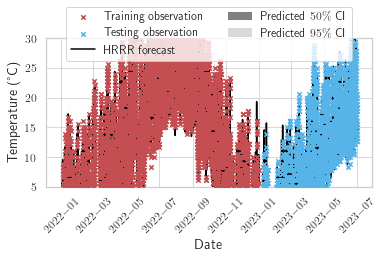

In [159]:
plot_time_series()

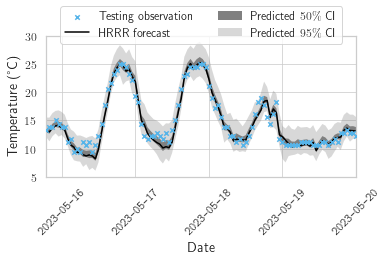

In [19]:
start=12004-9
stop= start+101
plot_time_series([start,stop])

In [20]:
ind = np.argsort(y_test)
min_ind = ind[0]
med_ind = ind[len(y_test)//2]
max_ind = ind[-1]
val_scenarios = [min_ind, med_ind, max_ind]

In [ ]:
easyUQ_data = np.load('../DIA_data/easyUQ_compare.npz')
easyUQ = easyUQ_data['EasyUQ'] # testing data quantiles: [0.025, 0.25, 0.50, 0.75, 0.975]
CP = easyUQ_data['CP'] # testing data ensemble of predictions

In [ ]:
data_CP = [CP[min_ind,:], CP[med_ind,:], CP[max_ind, :]]
data_CP = np.percentile(data_CP, [2.5, 25, 50, 75, 97.575], axis=1).T

In [ ]:
data_easy = [easyUQ[min_ind,:], easyUQ[med_ind,:], easyUQ[max_ind, :]]

In [24]:
num_val = len(val_scenarios)
num_samp=1000
data1 = np.zeros((num_val, num_samp))
if dist == "TPG":
    for i in range(num_val):
        index = val_scenarios[i]
        dist_obj = tpnorm(loc=f[index], sigma1=median_var1[index], sigma2=median_var2[index])
        data1[i,:] = dist_obj.random_sample(size=num_samp)
elif dist == "AL":
    for i in range(num_val):
        index = val_scenarios[i]
        data1[i,:] = laplace_asymmetric.rvs(median_var1[index], loc=f[index],
                                        scale=median_var2[index], size=num_samp)

In [ ]:
if dist == "TPG":
    data_TPG = np.percentile(data1, [2.5, 25, 50, 75, 97.575], axis=1).T
    np.savez('../DIA_data/TPG_compare.npz', data_TPG=data_TPG)  
elif dist == "AL":
    data = np.load('../DIA_data/TPG_compare.npz')
    data_TPG = data['data_TPG']
    data_AL = np.percentile(data1, [2.5, 25, 50, 75, 97.575], axis=1).T

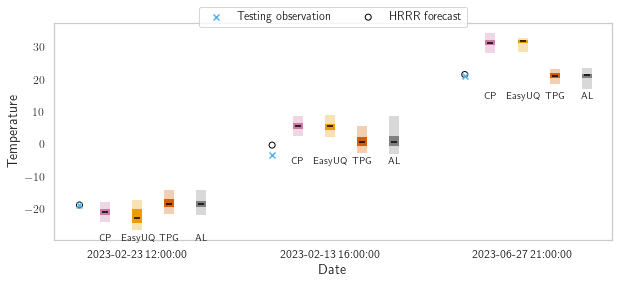

In [44]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Combine the three distributions
data = [data1[0,:], data1[1,:], data1[2,:]]

n_groups = len(val_scenarios)
width = 0.4
pos1 = np.arange(n_groups) * 3.0
pos2 = pos1 + width + 0.1
pos3 = pos2 + width + 0.1
pos4 = pos3 + width + 0.1

# Create a boxplot

fig, ax = plt.subplots(figsize=(10, 4))
# ax.boxplot(data, showfliers=False, positions=pos1, widths=width)
# ax.boxplot(data_CP, showfliers=False, positions=pos2, widths=width)

plt.scatter(pos1-width, y[val_scenarios], marker='x', color=cud_colors["sky_blue"],label="Testing observation", zorder=5)
plt.scatter(pos1-width, f[val_scenarios], marker='o', edgecolor='black', facecolor='none' ,label="HRRR forecast", zorder=3)

for i in range(n_groups):
    plt.errorbar(pos1[i], data_CP[i][2], yerr=[[data_CP[i][2]-data_CP[i][0]], [data_CP[i][4]-data_CP[i][2]]],
                linewidth=10, color=cud_colors['reddish_purple'], alpha=0.3)
    plt.errorbar(pos1[i], data_CP[i][2], yerr=[[data_CP[i][2]-data_CP[i][1]], [data_CP[i][3]-data_CP[i][2]]],
                linewidth=10, color=cud_colors['reddish_purple'], alpha=1.0)
    plt.scatter(pos1[i], data_CP[i][2], color='black', s=40, zorder=5, marker = '_')
    
    plt.errorbar(pos2[i], data_easy[i][2], yerr=[[data_easy[i][2]-data_easy[i][0]], [data_easy[i][4]-data_easy[i][2]]],
                linewidth=10, color=cud_colors['orange'], alpha=0.3)
    plt.errorbar(pos2[i], data_easy[i][2], yerr=[[data_easy[i][2]-data_easy[i][1]], [data_easy[i][3]-data_easy[i][2]]],
                linewidth=10, color=cud_colors['orange'], alpha=1.0)
    plt.scatter(pos2[i], data_easy[i][2], color='black', s=40, zorder=5, marker = '_')

    plt.errorbar(pos3[i], data_TPG[i][2], yerr=[[data_TPG[i][2]-data_TPG[i][0]], [data_TPG[i][4]-data_TPG[i][2]]],
                linewidth=10, color=cud_colors['vermillion'], alpha=0.3)
    plt.errorbar(pos3[i], data_TPG[i][2], yerr=[[data_TPG[i][2]-data_TPG[i][1]], [data_TPG[i][3]-data_TPG[i][2]]],
                linewidth=10, color=cud_colors['vermillion'], alpha=1.0)
    plt.scatter(pos3[i], data_TPG[i][2], color='black', s=40, zorder=5, marker = '_')

    if dist=="AL":
        plt.errorbar(pos4[i], data_AL[i][2], yerr=[[data_AL[i][2]-data_AL[i][0]], [data_AL[i][4]-data_AL[i][2]]],
                    linewidth=10, color='gray', alpha=0.3)
        plt.errorbar(pos4[i], data_AL[i][2], yerr=[[data_AL[i][2]-data_AL[i][1]], [data_AL[i][3]-data_AL[i][2]]],
                    linewidth=10, color='gray', alpha=1.0)
        plt.scatter(pos4[i], data_AL[i][2], color='black', s=40, zorder=5, marker = '_')

# Annotate each method below the x-axis
for i in range(n_groups):
    y_min = min(data_CP[i][0], data_easy[i][0], data_TPG[i][0], data_AL[i][0])  # Optional: align text below CIs
    offset = 1.0  # vertical spacing below the lowest CI

    ax.text(pos1[i], y_min - offset, "CP", ha='center', va='top', fontsize=10)
    ax.text(pos2[i], y_min - offset, "EasyUQ", ha='center', va='top', fontsize=10)
    ax.text(pos3[i], y_min - offset, "TPG", ha='center', va='top', fontsize=10)
    
    if dist == "AL":
        ax.text(pos4[i], y_min - offset, "AL", ha='center', va='top', fontsize=10)


# Adding titles and labels
# plt.title('Boxplot of Two-Piece Gaussian Distribution ACCRUE')
plt.xlabel('Date')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1),
          ncol=2, fancybox=True, shadow=False)
plt.ylabel('Temperature')
ax.set_xticks((pos1+pos3)/2)
ax.set_xticklabels([test_times[min_ind], test_times[med_ind], test_times[max_ind]])

# plt.ylim((-2,25))
# plt.xticks(rotation=45)
plt.grid(False)
plt.savefig("../graphs/boxplots.pdf", bbox_inches="tight")